In [1]:
# this is to check if the labels I am using are correct
import os

In [2]:
# MY_LABEL_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset333_Autopet/nnUNetPlans_3d_fullres'
# CORRECT_LABEL_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_Autopet/nnUNetPlans_3d_fullres'
# HARD_LABELS_DIR   = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
# PSEUDO_LABELS_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/train_predictions'
# VAL_LABELS_DIR    = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/val_labels'
# TEST_LABELS_DIR  = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/test/gt'

# os.path.exists(CORRECT_LABEL_DIR)

# # load a random label file from my directory and the correct directory and compare them
# import numpy as np
# label_prefix = "fdg"
# files_with_prefix = [f for f in os.listdir(CORRECT_LABEL_DIR) if f.startswith(label_prefix) and f.endswith('9.npy')]
# print(files_with_prefix)

In [2]:
# This is the directory I'm going to use for training
import os

DIR_TO_CHECK_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet/nnUNetPlans_3d_fullres/'
HARD_LABELS_DIR   = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/'
PSEUDO_LABELS_DIR = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0_10/train_tta_predicted/train_predictions/converted_segs'
VAL_LABELS_DIR    = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/'
TEST_LABELS_DIR  = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/'

for d in [DIR_TO_CHECK_DIR, HARD_LABELS_DIR, PSEUDO_LABELS_DIR, VAL_LABELS_DIR, TEST_LABELS_DIR]:
    print(f"Checking directory: {d}")
    if os.path.exists(d):
        print(f" EXISTS: {d}")
        # files = os.listdir(d)
        # print(f"\t Number of files: {len(files)}")
    else:
        print(f"NOT EXIST: {d}")


Checking directory: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet/nnUNetPlans_3d_fullres/
 EXISTS: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet/nnUNetPlans_3d_fullres/
Checking directory: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/
 EXISTS: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/
Checking directory: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0_10/train_tta_predicted/train_predictions/converted_segs
 EXISTS: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0_10/train_tta_predicted/train_predictions/converted_segs
Checking directory: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPl

In [3]:
import json 
import numpy as np


SPLITS_DIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/splits_final.json'
with open(SPLITS_DIR, 'r') as f:
    splits = json.load(f)


labelled   = set(splits[0]['train'])
all_files  = set(splits[6]['train'])
unlabelled = all_files - labelled
val_files  = set(splits[0]['val'])

# load a random validation file from the val_labels directory and check if it matches the name of the file in the splits
val_file = list(val_files)[0]
val_file_path = os.path.join(VAL_LABELS_DIR, val_file + '.npy')
check_val_file_path = os.path.join(DIR_TO_CHECK_DIR, val_file + '.npy')

print(f"Checking validation file: {val_file_path}")
if os.path.exists(val_file_path):
    print(f" EXISTS: {val_file_path}")
    
# load both of the validation files and check if they are the same
import nibabel as nib
val_img = np.load(val_file_path)
check_val_img = np.load(check_val_file_path)
if np.array_equal(val_img, check_val_img):
    print("Validation files match!")


Checking validation file: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/fdg_39159c05c2_02-23-2001-NA-PET-CT Ganzkoerper  primaer mit KM-64318.npy
 EXISTS: /lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_AutoPet/nnUNetPlans_3d_fullres/fdg_39159c05c2_02-23-2001-NA-PET-CT Ganzkoerper  primaer mit KM-64318.npy


OSError: [Errno 22] Invalid argument: '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset901_AutoPet/nnUNetPlans_3d_fullres/fdg_39159c05c2_02-23-2001-NA-PET-CT Ganzkoerper  primaer mit KM-64318.npy'

In [ ]:
# load the label from both directories
my_label_path = os.path.join(MY_LABEL_DIR, files_with_prefix[0])
correct_label_path = os.path.join(CORRECT_LABEL_DIR, files_with_prefix[0])

my_label = np.load(my_label_path)
correct_label = np.load(correct_label_path)
# compare the two labels
if np.array_equal(my_label, correct_label):
    print("The labels are the same.")
    

    

FileNotFoundError: [Errno 2] No such file or directory: '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset333_Autopet/nnUNetPlans_3d_fullres\\fdg_d951eeb735_01-23-2003-NA-PET-CT Ganzkoerper  primaer mit KM-21299.npy'

In [13]:
correct_label_path

'/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset888_Autopet/nnUNetPlans_3d_fullres\\psma_3f391a1e890184b2_2020-05-09.npy'

In [26]:
 correct_label.shape

(2, 287, 344, 344)

In [27]:
# what are the means
# print("My label mean:", np.mean(my_label))
print("Correct label mean:", np.mean(correct_label))

Correct label mean: -1.8628044


In [6]:
if np.array_equal(my_label, correct_label):
    print("The labels are the same.")
    


Text(0.5, 1.0, 'Correct Label Z-Project')

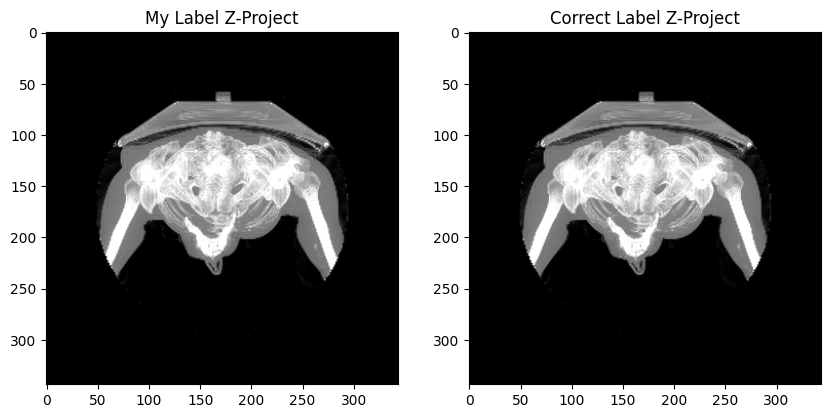

In [9]:
# plot the z project 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.max(my_label[0], axis=0), cmap='gray')
plt.title('My Label Z-Project')
plt.subplot(1, 2, 2)
plt.imshow(np.max(correct_label[0], axis=0), cmap='gray')
plt.title('Correct Label Z-Project')